### **Importation des bibliothèque nécessaire**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

### **Chargement des données**

In [2]:
df = pd.read_csv('ex2data1.txt',header=None, names=["Note 1","Note 2","Resultat"])

In [3]:
df.head()

,Note 1,Note 2,Resultat
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Note 1    100 non-null    float64
 1   Note 2    100 non-null    float64
 2   Resultat  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [5]:
df.duplicated().sum()

np.int64(0)

Pas de doublon

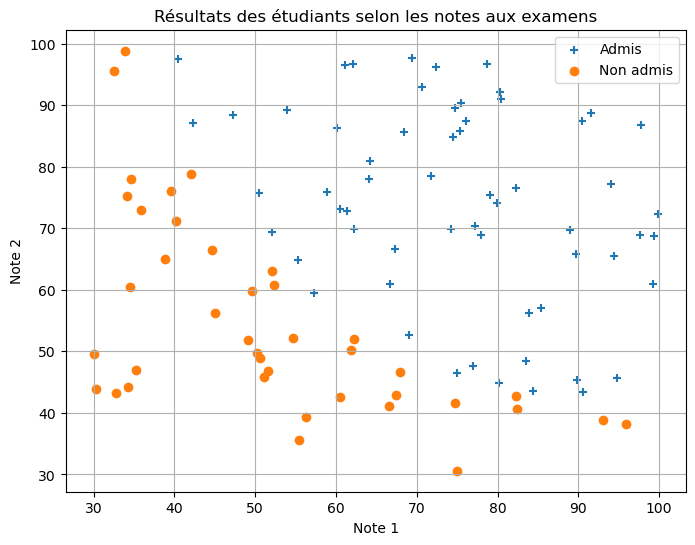

In [6]:
# Séparer les étudiants admis et non admis
admis = df[df["Resultat"] == 1]
non_admis = df[df["Resultat"] == 0]

# Créer le nuage de points
plt.figure(figsize=(8, 6))

plt.scatter(
    admis["Note 1"],
    admis["Note 2"],
    label="Admis",
    marker="+"
)

plt.scatter(
    non_admis["Note 1"],
    non_admis["Note 2"],
    label="Non admis",
    marker="o"
)

plt.xlabel("Note 1")
plt.ylabel("Note 2")
plt.title("Résultats des étudiants selon les notes aux examens")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
df['Resultat'].value_counts()

Resultat
1    60
0    40
Name: count, dtype: int64

### **Division de nos données en données d'entrainement et de teste**

In [8]:
X = df.drop('Resultat',axis=1)
y = df['Resultat']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [10]:
X

,Note 1,Note 2
0,34.623660,78.024693
1,30.286711,43.894998
2,35.847409,72.902198
3,60.182599,86.308552
4,79.032736,75.344376
...,...,...
95,83.489163,48.380286
96,42.261701,87.103851
97,99.315009,68.775409
98,55.340018,64.931938


In [11]:
y

0     0
1     0
2     0
3     1
4     1
     ..
95    1
96    1
97    1
98    1
99    1
Name: Resultat, Length: 100, dtype: int64

### **Normalisation des données**

In [12]:
scaler = StandardScaler()

In [13]:
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.fit_transform(X_test)

### **Implémentation du modèle**

Par défaut, vu que les classes ne sont pas trop désequilibrés, le class-weight peut-être laissé par défaut

In [14]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaler,y_train)
y_pred = lr.predict(X_test_scaler)

### **Evaluation du modèle**

In [15]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1:", round(f1,4))
print(classification_report(y_test, y_pred))

Accuracy: 0.9
Precision: 0.9167
Recall: 0.9167
F1: 0.9167
              precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.92      0.92      0.92        12

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20



On remarque que le modèle affiche de bons résultats concernant les prédictions, déjà il a une meilleure précision en fonction de chaque classe, donc arrive à les distinguer, et les résultats du recall et du f1-score appuient notre décision.

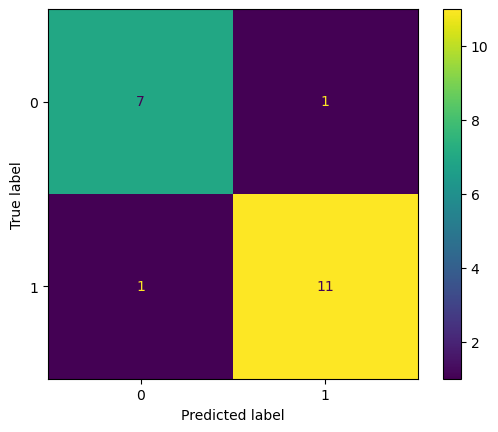

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

Dans notre matrice de confusion, on voit que le modèle s'est trompé quelques rares fois. Sur 8 étudiants ayant validé, il en a trouvé 7 et s'est trompé sur 1. Pareil aussi sur les 12 étudiants n'ayant pas validé, il a prédit 11 correctement et s'est trompé sur un étudiant.